# Modèle 2 — Random Forest

## Qu'est-ce que le Random Forest ?
Le Random Forest est un ensemble de plusieurs arbres de décision.
Chaque arbre apprend sur une partie aléatoire des données, 
puis on combine leurs prédictions (vote majoritaire).

## Pourquoi après la Régression Logistique ?
- Capture les relations **non-linéaires** que la LR ne voit pas
- Robuste aux outliers (on en a dans notre dataset)
- Pas besoin de scaling (mais nos données sont déjà standardisées)
- Fournit une **feature importance** native

## Avantages
- Très performant sur les données tabulaires
- Résistant au surapprentissage grâce à l'ensemble de d'arbres
- Feature importance interprétable

## Limites
- Plus lent à entraîner que la régression logistique
- Moins interprétable qu'un seul arbre

## Tâches
- **Tâche 1** : Classification — prédire `churn` (0/1)
- **Tâche 2** : Régression — prédire `revenue_at_risk`

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    roc_curve, mean_absolute_error, 
    mean_squared_error, r2_score
)

RANDOM_STATE = 42
os.makedirs('../models', exist_ok=True)
os.makedirs('../results', exist_ok=True)

print("Imports OK")

Imports OK


## Chargement des données preprocessées

Mêmes données que pour la Régression Logistique.
On charge les fichiers .npy générés par le preprocessing.

In [2]:
X_train = np.load('../data/processed/X_train.npy')
X_test  = np.load('../data/processed/X_test.npy')

y_train_clf = np.load('../data/processed/y_train_clf.npy')
y_test_clf  = np.load('../data/processed/y_test_clf.npy')

y_train_reg = np.load('../data/processed/y_train_reg.npy')
y_test_reg  = np.load('../data/processed/y_test_reg.npy')

feature_names = pd.read_csv('../data/processed/feature_names.csv')['0'].tolist()

print(f"Données chargées")
print(f"   X_train : {X_train.shape}")
print(f"   X_test  : {X_test.shape}")
print(f"   Churners dans test : {y_test_clf.sum()} ({y_test_clf.mean()*100:.1f}%)")

Données chargées
   X_train : (8000, 51)
   X_test  : (2000, 51)
   Churners dans test : 204 (10.2%)


## Tâche 1 — Classification du Churn

Paramètres importants :
- `n_estimators=200` → 200 arbres dans la forêt
- `class_weight='balanced'` → compense le déséquilibre 10/90%
- `max_depth=10` → limite la profondeur pour éviter le surapprentissage
- `random_state=42` → reproductibilité

In [3]:
# ============================================================
# TÂCHE 1 — CLASSIFICATION
# ============================================================

rf_clf = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    max_depth=10,
    min_samples_leaf=5,
    random_state=RANDOM_STATE,
    n_jobs=-1  # Utilise tous les CPU disponibles
)

rf_clf.fit(X_train, y_train_clf)

y_pred_clf  = rf_clf.predict(X_test)
y_proba_clf = rf_clf.predict_proba(X_test)[:, 1]

print("Modèle entraîné !")
print(f"\n Résultats — Random Forest (Classification)")
print(f"   Accuracy  : {accuracy_score(y_test_clf, y_pred_clf):.4f}")
print(f"   Precision : {precision_score(y_test_clf, y_pred_clf):.4f}")
print(f"   Recall    : {recall_score(y_test_clf, y_pred_clf):.4f}")
print(f"   F1-Score  : {f1_score(y_test_clf, y_pred_clf):.4f}")
print(f"   ROC-AUC   : {roc_auc_score(y_test_clf, y_proba_clf):.4f}")

Modèle entraîné !

 Résultats — Random Forest (Classification)
   Accuracy  : 0.8355
   Precision : 0.2990
   Recall    : 0.4559
   F1-Score  : 0.3612
   ROC-AUC   : 0.7993


## Matrice de Confusion

On compare avec la Régression Logistique :
- Moins de Faux Négatifs = moins de churners manqués
- Baseline LR avait : FN=71, TP=133

L'objectif est de réduire les FN (churners non détectés).

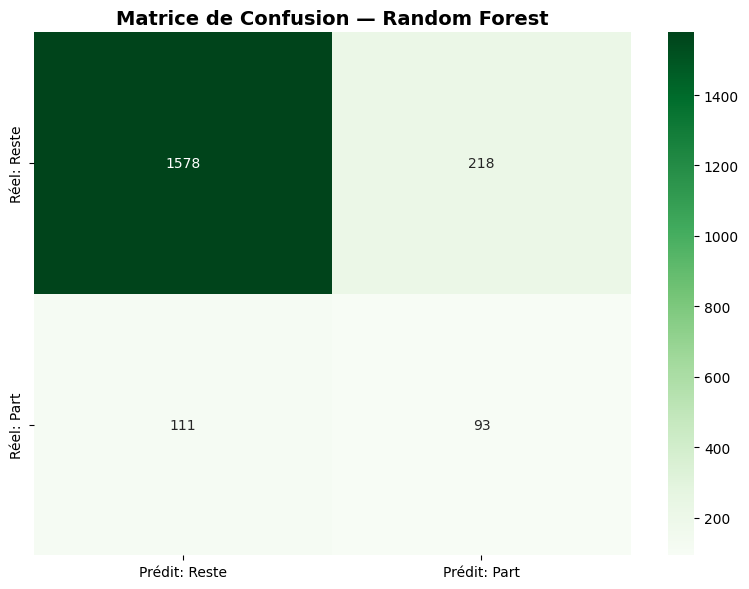


Analyse de la matrice :
   Vrais Négatifs  (TN) : 1578
   Faux Positifs   (FP) : 218
   Faux Négatifs   (FN) : 111 → churners manqués 
   Vrais Positifs  (TP) : 93 → churners détectés 

 Comparaison baseline LR :
   LR  → FN=71,  TP=133
   RF  → FN=111, TP=93


In [7]:
# ============================================================
# MATRICE DE CONFUSION
# ============================================================

cm = confusion_matrix(y_test_clf, y_pred_clf)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Prédit: Reste', 'Prédit: Part'],
            yticklabels=['Réel: Reste', 'Réel: Part'])
plt.title('Matrice de Confusion — Random Forest',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/rf_confusion_matrix.png', dpi=150)
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"\nAnalyse de la matrice :")
print(f"   Vrais Négatifs  (TN) : {tn}")
print(f"   Faux Positifs   (FP) : {fp}")
print(f"   Faux Négatifs   (FN) : {fn} → churners manqués ")
print(f"   Vrais Positifs  (TP) : {tp} → churners détectés ")
print(f"\n Comparaison baseline LR :")
print(f"   LR  → FN=71,  TP=133")
print(f"   RF  → FN={fn}, TP={tp}")

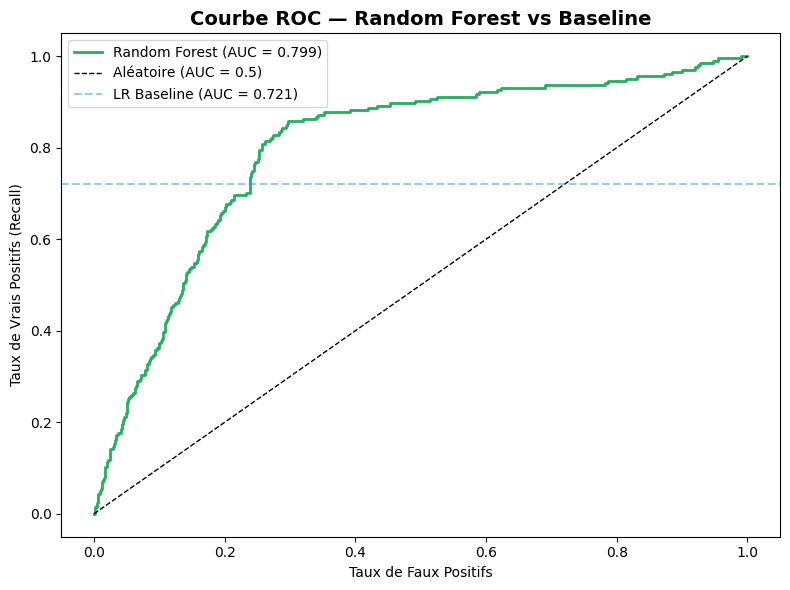

In [8]:
# ============================================================
# COURBE ROC — Comparaison avec LR
# ============================================================

fpr, tpr, _ = roc_curve(y_test_clf, y_proba_clf)
auc = roc_auc_score(y_test_clf, y_proba_clf)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='#27ae60', linewidth=2,
         label=f'Random Forest (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, 
         label='Aléatoire (AUC = 0.5)')
plt.axhline(y=0.7212, color='#3498db', linestyle='--', 
            alpha=0.5, label='LR Baseline (AUC = 0.721)')
plt.xlabel('Taux de Faux Positifs')
plt.ylabel('Taux de Vrais Positifs (Recall)')
plt.title('Courbe ROC — Random Forest vs Baseline',
          fontsize=14, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('../results/rf_roc_curve.png', dpi=150)
plt.show()

## 🔍 Feature Importance

Un des grands avantages du Random Forest est qu'il calcule 
automatiquement l'importance de chaque variable.

Plus une variable est importante :
- Plus elle est utilisée pour séparer les données dans les arbres
- Plus elle contribue à la prédiction finale du churn

Ces résultats sont cohérents avec notre EDA — les variables 
identifiées comme importantes ici doivent correspondre aux 
signaux forts détectés lors de l'analyse exploratoire.

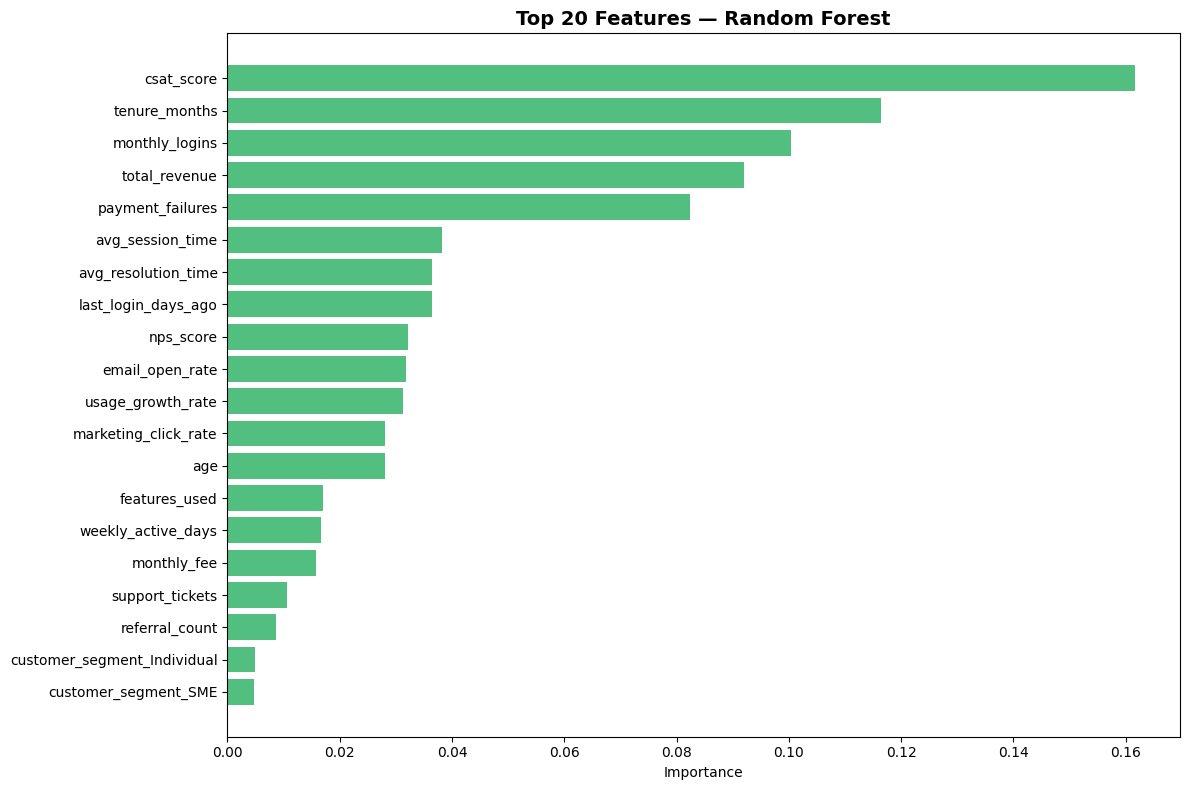


🔝 Top 10 features les plus importantes :
   1. csat_score                          : 0.1616
   2. tenure_months                       : 0.1165
   3. monthly_logins                      : 0.1004
   4. total_revenue                       : 0.0921
   5. payment_failures                    : 0.0825
   6. avg_session_time                    : 0.0382
   7. avg_resolution_time                 : 0.0365
   8. last_login_days_ago                 : 0.0364
   9. nps_score                           : 0.0322
   10. email_open_rate                     : 0.0317


In [9]:
# ============================================================
# FEATURE IMPORTANCE
# ============================================================

importances = rf_clf.feature_importances_
indices = np.argsort(importances)[::-1][:20]  # Top 20

plt.figure(figsize=(12, 8))
plt.barh(range(20), 
         importances[indices][::-1],
         color='#27ae60', alpha=0.8)
plt.yticks(range(20), 
           [feature_names[i] for i in indices][::-1],
           fontsize=10)
plt.xlabel('Importance')
plt.title('Top 20 Features — Random Forest',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/rf_feature_importance.png', dpi=150)
plt.show()

print("\n🔝 Top 10 features les plus importantes :")
for i in range(10):
    print(f"   {i+1}. {feature_names[indices[i]]:35} : {importances[indices[i]]:.4f}")

## 💰 Tâche 2 — Régression du Revenu à Risque

On utilise RandomForestRegressor pour prédire le revenu à risque.

Avantage vs Ridge Regression :
- Capture les relations non-linéaires
- Meilleur R² attendu car les arbres s'adaptent mieux
  à la distribution très asymétrique de revenue_at_risk

In [10]:
# ============================================================
# TÂCHE 2 — RÉGRESSION
# ============================================================

rf_reg = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=5,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_reg.fit(X_train, y_train_reg)

y_pred_reg = rf_reg.predict(X_test)
y_pred_reg = np.maximum(y_pred_reg, 0)

mae  = mean_absolute_error(y_test_reg, y_pred_reg)
rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg))
r2   = r2_score(y_test_reg, y_pred_reg)

print("Modèle de régression entraîné !")
print(f"\n Résultats — Random Forest Regression")
print(f"   MAE  : {mae:.2f} €")
print(f"   RMSE : {rmse:.2f} €")
print(f"   R²   : {r2:.4f}")
print(f"\n Comparaison baseline Ridge :")
print(f"   Ridge → MAE=156.11€, R²=0.0533")
print(f"   RF    → MAE={mae:.2f}€,  R²={r2:.4f}")

Modèle de régression entraîné !

 Résultats — Random Forest Regression
   MAE  : 145.39 €
   RMSE : 373.57 €
   R²   : 0.0612

 Comparaison baseline Ridge :
   Ridge → MAE=156.11€, R²=0.0533
   RF    → MAE=145.39€,  R²=0.0612


In [12]:
# ============================================================
# SAUVEGARDE
# ============================================================

joblib.dump(rf_clf, '../models/rf_classification.pkl')
joblib.dump(rf_reg, '../models/rf_regression.pkl')

results_clf = {
    'model'    : 'Random Forest',
    'accuracy' : accuracy_score(y_test_clf, y_pred_clf),
    'precision': precision_score(y_test_clf, y_pred_clf),
    'recall'   : recall_score(y_test_clf, y_pred_clf),
    'f1'       : f1_score(y_test_clf, y_pred_clf),
    'roc_auc'  : roc_auc_score(y_test_clf, y_proba_clf)
}

results_reg = {
    'model': 'Random Forest Regression',
    'mae' : mae,
    'rmse': rmse,
    'r2'  : r2
}

pd.DataFrame([results_clf]).to_csv('../results/rf_clf_results.csv', index=False)
pd.DataFrame([results_reg]).to_csv('../results/rf_reg_results.csv', index=False)

print("Modèles sauvegardés dans ../models/")
print("Résultats sauvegardés dans ../results/")
print(f"\nRésumé Classification :")
for k, v in results_clf.items():
    if k != 'model':
        print(f"   {k:10} : {v:.4f}")

Modèles sauvegardés dans ../models/
Résultats sauvegardés dans ../results/

Résumé Classification :
   accuracy   : 0.8355
   precision  : 0.2990
   recall     : 0.4559
   f1         : 0.3612
   roc_auc    : 0.7993


## Synthèse — Random Forest

### Comparaison avec la Baseline (Régression Logistique)
| Métrique | LR Baseline | Random Forest | Amélioration |
|---|---|---|---|
| Accuracy | 0.6685 | 0.8355 | +0.1670 |
| Precision | 0.1834 | 0.2990 | +0.1156 |
| Recall | 0.6520 | 0.4559 | -0.1961  |
| F1-Score | 0.2863 | 0.3612 | +0.0749  |
| ROC-AUC | 0.7212 | 0.7993 | +0.0781  |

### Régression
| Métrique | Ridge Baseline | Random Forest | Amélioration |
|---|---|---|---|
| MAE | 156.11€ | 145.39€ | -10.72€  |
| R² | 0.0533 | 0.0612 | +0.0079  |

### Analyse des résultats
Le Random Forest améliore globalement la baseline SAUF sur le Recall
qui baisse de 0.652 à 0.456. Cela signifie qu'on détecte moins 
de churners mais avec plus de précision.

⚠️ Dans notre contexte business le Recall est crucial — 
manquer un churner coûte 845€. On devra donc privilégier 
le modèle avec le meilleur Recall lors du choix final.

### Points forts
- F1-Score amélioré 
- ROC-AUC meilleur 
- Feature importance disponible 

### Limites
- Recall inférieur à la LR 
- Plus lent à entraîner 

### ➡️ Prochaine étape
XGBoost → algorithme de boosting, potentiellement meilleur
sur les deux métriques simultanément